Import all Libraries

In [11]:
# Cell 1: Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import dlib
import urllib.request
import os

print("="*50)
print("📊 PHASE 2: FACE DETECTION")
print("="*50)
print(f"✅ OpenCV version: {cv2.__version__}")
print(f"✅ dlib version: {dlib.__version__}")
print("✅ All imports successful!")

📊 PHASE 2: FACE DETECTION
✅ OpenCV version: 4.8.1
✅ dlib version: 20.0.1
✅ All imports successful!


Load dlib's Face Detector

In [12]:
# Cell 2: Load Face Detectors
print("\n📥 Loading face detectors...")

# OpenCV detector (Haar Cascade)
opencv_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
print(f"✅ OpenCV detector loaded: {not opencv_detector.empty()}")

# dlib detector (HOG + Linear SVM)
dlib_detector = dlib.get_frontal_face_detector()
print(f"✅ dlib detector loaded: {dlib_detector is not None}")

print("\n✅ Both detectors ready!")


📥 Loading face detectors...
✅ OpenCV detector loaded: True
✅ dlib detector loaded: True

✅ Both detectors ready!


Download Sample Image


📥 Downloading sample image...
✅ Image already exists!


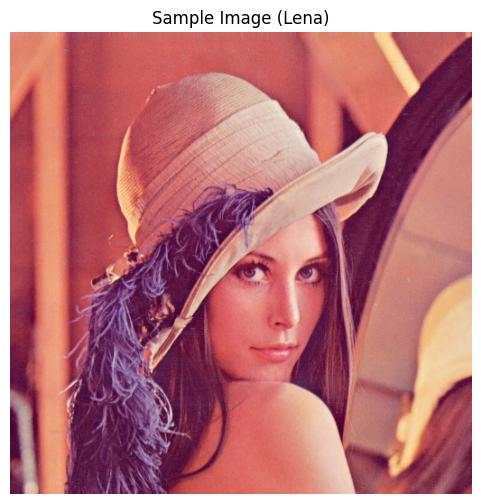

📊 Image shape: (512, 512, 3)


In [13]:
# Cell 3: Download Sample Image
print("\n📥 Downloading sample image...")

url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
filename = "lena.jpg"

if not os.path.exists(filename):
    urllib.request.urlretrieve(url, filename)
    print("✅ Image downloaded!")
else:
    print("✅ Image already exists!")

# Load and display image
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Sample Image (Lena)")
plt.axis('off')
plt.show()

print(f"📊 Image shape: {img.shape}")

Detect Faces with OpenCV


🔍 Detecting faces with OpenCV...
✅ OpenCV found: 1 face(s)
   Face 1: x=219, y=203, w=169, h=169


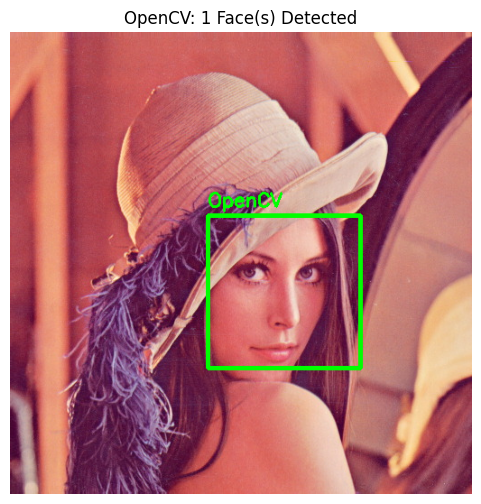

In [14]:
# Cell 4: Detect Faces with OpenCV
print("\n🔍 Detecting faces with OpenCV...")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces_opencv = opencv_detector.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print(f"✅ OpenCV found: {len(faces_opencv)} face(s)")

# Show results
if len(faces_opencv) > 0:
    for i, (x, y, w, h) in enumerate(faces_opencv):
        print(f"   Face {i+1}: x={x}, y={y}, w={w}, h={h}")
    
    # Draw rectangles
    img_opencv = img.copy()
    for (x, y, w, h) in faces_opencv:
        cv2.rectangle(img_opencv, (x, y), (x+w, y+h), (0, 255, 0), 3)
        cv2.putText(img_opencv, 'OpenCV', (x, y-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    
    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_opencv, cv2.COLOR_BGR2RGB))
    plt.title(f"OpenCV: {len(faces_opencv)} Face(s) Detected")
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No faces detected by OpenCV")

Detect Faces with dlib


🔍 Detecting faces with dlib...
✅ dlib found: 1 face(s)
   Face 1: x=228, y=228, w=150, h=150


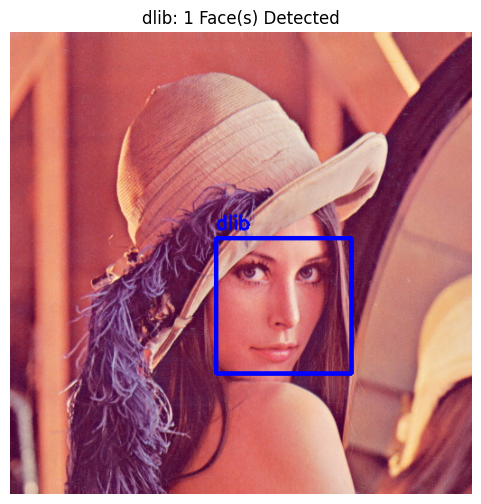

In [15]:
# Cell 5: Detect Faces with dlib
print("\n🔍 Detecting faces with dlib...")

# dlib works on RGB images
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
faces_dlib = dlib_detector(rgb)

print(f"✅ dlib found: {len(faces_dlib)} face(s)")

# Show results
if len(faces_dlib) > 0:
    for i, face in enumerate(faces_dlib):
        x = face.left()
        y = face.top()
        w = face.width()
        h = face.height()
        print(f"   Face {i+1}: x={x}, y={y}, w={w}, h={h}")
    
    # Draw rectangles
    img_dlib = img.copy()
    for face in faces_dlib:
        x = face.left()
        y = face.top()
        w = face.width()
        h = face.height()
        cv2.rectangle(img_dlib, (x, y), (x+w, y+h), (255, 0, 0), 3)
        cv2.putText(img_dlib, 'dlib', (x, y-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
    
    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_dlib, cv2.COLOR_BGR2RGB))
    plt.title(f"dlib: {len(faces_dlib)} Face(s) Detected")
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No faces detected by dlib")

Compare Both Detectors


📊 Comparing OpenCV vs dlib...


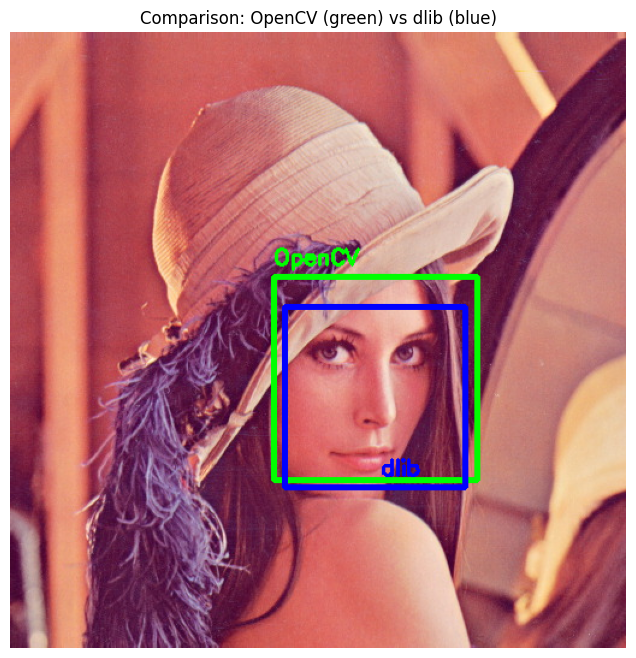


📊 Summary:
   OpenCV: 1 face(s)
   dlib:   1 face(s)


In [16]:
# Cell 6: Compare Both Detectors
print("\n📊 Comparing OpenCV vs dlib...")

# Create image with both detections
img_compare = img.copy()

# OpenCV (green)
for (x, y, w, h) in faces_opencv:
    cv2.rectangle(img_compare, (x, y), (x+w, y+h), (0, 255, 0), 3)
    cv2.putText(img_compare, 'OpenCV', (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# dlib (blue)
for face in faces_dlib:
    x = face.left()
    y = face.top()
    w = face.width()
    h = face.height()
    cv2.rectangle(img_compare, (x, y), (x+w, y+h), (255, 0, 0), 3)
    cv2.putText(img_compare, 'dlib', (x+w-70, y+h-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Display
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img_compare, cv2.COLOR_BGR2RGB))
plt.title('Comparison: OpenCV (green) vs dlib (blue)')
plt.axis('off')
plt.show()

print("\n📊 Summary:")
print(f"   OpenCV: {len(faces_opencv)} face(s)")
print(f"   dlib:   {len(faces_dlib)} face(s)")

dlib Facial Landmarks (68 Points)


🔍 Extracting facial landmarks...
✅ Found 68 facial landmarks


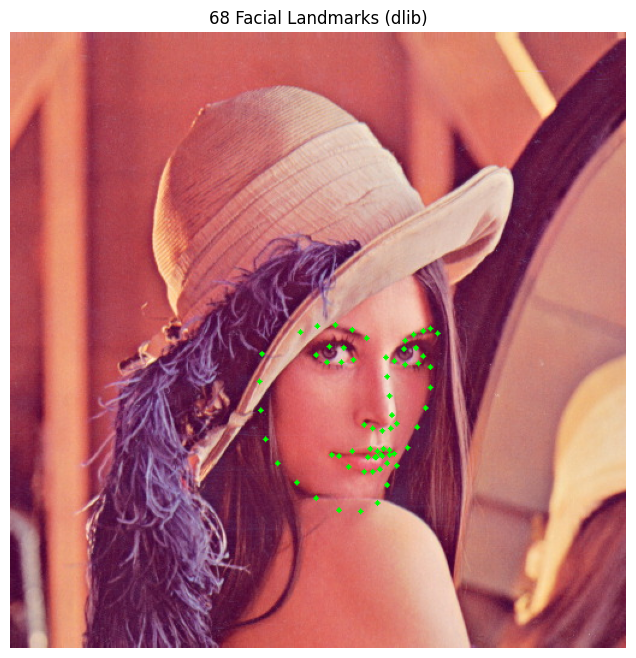

In [17]:
# Cell 7: Facial Landmarks with dlib
print("\n🔍 Extracting facial landmarks...")

# Download landmark predictor if not exists
landmark_url = "http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2"
landmark_file = "shape_predictor_68_face_landmarks.dat"

if not os.path.exists(landmark_file):
    print("📥 Downloading landmark model (large file, may take a moment)...")
    import bz2
    urllib.request.urlretrieve(landmark_url, landmark_file + ".bz2")
    
    # Extract
    with open(landmark_file + ".bz2", 'rb') as f:
        data = bz2.decompress(f.read())
    with open(landmark_file, 'wb') as f:
        f.write(data)
    os.remove(landmark_file + ".bz2")
    print("✅ Landmark model downloaded and extracted!")

# Load predictor
predictor = dlib.shape_predictor(landmark_file)

if len(faces_dlib) > 0:
    # Get first face
    face = faces_dlib[0]
    
    # Get landmarks
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    landmarks = predictor(gray, face)
    
    print(f"✅ Found {landmarks.num_parts} facial landmarks")
    
    # Draw landmarks
    img_landmarks = img.copy()
    for i in range(landmarks.num_parts):
        x = landmarks.part(i).x
        y = landmarks.part(i).y
        cv2.circle(img_landmarks, (x, y), 2, (0, 255, 0), -1)
    
    # Display
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(img_landmarks, cv2.COLOR_BGR2RGB))
    plt.title(f'68 Facial Landmarks (dlib)')
    plt.axis('off')
    plt.show()
else:
    print("⚠️ No face detected to show landmarks")

Phase 2 Summary

In [18]:
# Cell 8: Phase 2 Summary
print("\n" + "="*50)
print("📊 PHASE 2: FACE DETECTION - SUMMARY")
print("="*50)

print("\n✅ What we learned:")
print("   1. Face detection with OpenCV (Haar Cascade)")
print("   2. Face detection with dlib (HOG + SVM)")
print("   3. 68 facial landmarks with dlib")
print("   4. Comparing detection methods")

print("\n📊 Results:")
print(f"   OpenCV: {len(faces_opencv)} face(s) detected")
print(f"   dlib:   {len(faces_dlib)} face(s) detected")
print(f"   Landmarks: {len(landmarks.parts()) if len(faces_dlib) > 0 else 'N/A'} points extracted")

print("\n📚 Key Concepts:")
print("   - Haar Cascades: Fast but less accurate")
print("   - HOG + SVM: More accurate but slower")
print("   - Facial Landmarks: 68 key points on the face")
print("   - Eye Aspect Ratio (EAR): Coming in Phase 3!")

print("\n✅ PHASE 2 COMPLETE!")
print("🚀 Ready for Phase 3: Fatigue Detection!")


📊 PHASE 2: FACE DETECTION - SUMMARY

✅ What we learned:
   1. Face detection with OpenCV (Haar Cascade)
   2. Face detection with dlib (HOG + SVM)
   3. 68 facial landmarks with dlib
   4. Comparing detection methods

📊 Results:
   OpenCV: 1 face(s) detected
   dlib:   1 face(s) detected
   Landmarks: 68 points extracted

📚 Key Concepts:
   - Haar Cascades: Fast but less accurate
   - HOG + SVM: More accurate but slower
   - Facial Landmarks: 68 key points on the face
   - Eye Aspect Ratio (EAR): Coming in Phase 3!

✅ PHASE 2 COMPLETE!
🚀 Ready for Phase 3: Fatigue Detection!
